In [ ]:
!pip install transformers torch emoji openpyxl -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 2.9 MB/s eta 0:00:00


In [ ]:
import torch
import re
import emoji
import pandas as pd
from transformers import pipeline
import warnings
warnings.filterwarnings('ignore')

print("Loading model — downloads ~500MB first time only...")

sentiment_model = pipeline(
    "text-classification",
    model  = "cardiffnlp/twitter-roberta-base-sentiment-latest",
    device = 0 if torch.cuda.is_available() else -1
)

print(f"Model loaded!")
print(f"GPU: {'✅ Yes' if torch.cuda.is_available() else '❌ No — using CPU'}")

Loading model — downloads ~500MB first time only...


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Model loaded!
GPU: ❌ No — using CPU


In [ ]:
combined = pd.read_excel("/content/combined_lpg_data.xlsx")
print(f"Loaded: {combined.shape}")
print(combined.columns.tolist())
print(combined.head(3))

Loaded: (810, 6)
['sno', 'comment', 'hashtags', 'time', 'type', 'word_count']
   sno                                            comment    hashtags  \
0    1  q did people have to stand in queue for gas cy...        none   
1    2  india s lpg crisis is now rewriting menus in r...  #bengaluru   
2    3  gas cylinder booked on st march which delivere...        none   

        time type  word_count  
0 2026-05-03    x          25  
1 2026-05-03    x          11  
2 2026-05-03    x          18  


In [ ]:
def clean_comment(text):
    text = str(text)
    text = emoji.replace_emoji(text, replace='')
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

In [ ]:
from tqdm import tqdm
tqdm.pandas()

def get_bert_prediction(text):
    try:
        cleaned = clean_comment(str(text))
        if not cleaned.strip():
            return 'Neutral', 0.0
        result  = sentiment_model(cleaned[:512])[0]
        label   = result['label'].capitalize()
        score   = round(result['score'], 3)
        return label, score
    except:
        return 'Neutral', 0.0

print("Running BERT on all comments (~2-5 mins)...")
combined[['bert_label', 'bert_score']] = combined['comment'].progress_apply(
    lambda x: pd.Series(get_bert_prediction(x))
)

print("\nBERT label distribution:")
print(combined['bert_label'].value_counts())
print(f"\n{combined['bert_label'].value_counts(normalize=True).round(3)*100}")

Running BERT on all comments (~2-5 mins)...


100%|██████████| 810/810 [03:17<00:00,  4.10it/s]


BERT label distribution:
bert_label
Negative    391
Neutral     362
Positive     57
Name: count, dtype: int64

bert_label
Negative    48.3
Neutral     44.7
Positive     7.0
Name: proportion, dtype: float64


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

labelled = pd.read_excel("/content/manual_label_100.xlsx")
labelled = labelled[labelled['true_label'].notna()]
labelled['true_label'] = labelled['true_label'].str.strip().str.capitalize()
labelled['bert_label'] = labelled['bert_label'].str.strip().str.capitalize()

accuracy = accuracy_score(labelled['true_label'], labelled['bert_label'])

print(f"Total labelled  : {len(labelled)}")
print(f"\nBERT Accuracy   : {accuracy:.1%}")
print(f"\nDetailed Report:")
print(classification_report(labelled['true_label'], labelled['bert_label']))

Total labelled  : 100

BERT Accuracy   : 72.0%

Detailed Report:
              precision    recall  f1-score   support

    Negative       0.98      0.65      0.78        65
     Neutral       0.55      0.90      0.68        30
    Positive       0.38      0.60      0.46         5

    accuracy                           0.72       100
   macro avg       0.63      0.72      0.64       100
weighted avg       0.82      0.72      0.73       100



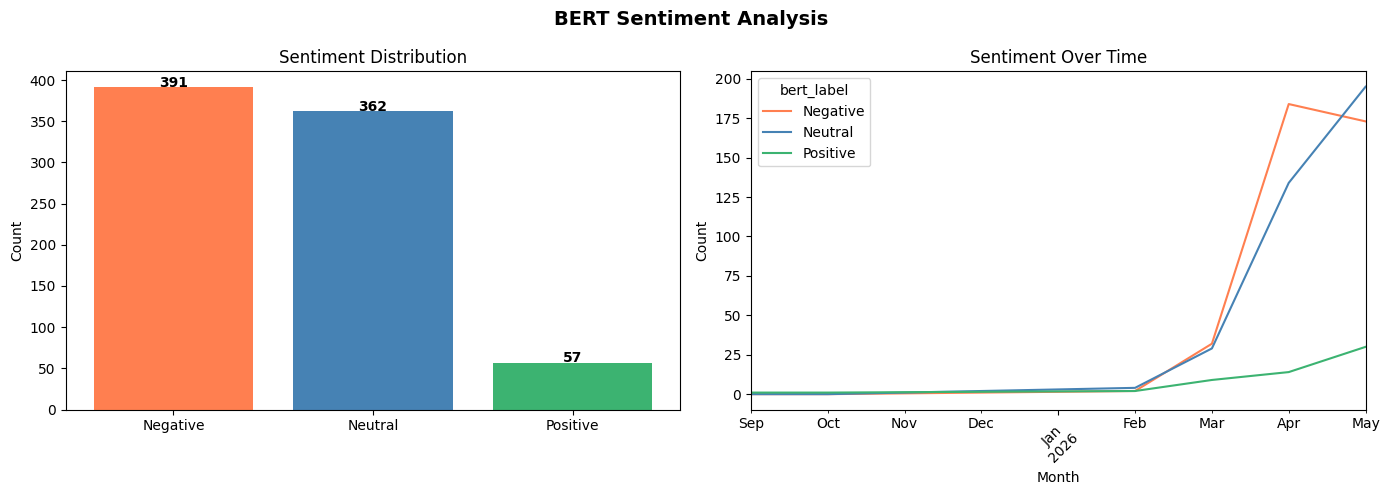

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('BERT Sentiment Analysis ',
             fontsize=14, fontweight='bold')

colors = {'Positive':'mediumseagreen',
          'Negative':'coral',
          'Neutral' :'steelblue'}

# Label distribution
bert_counts = combined['bert_label'].value_counts()
axes[0].bar(bert_counts.index, bert_counts.values,
            color=[colors.get(l,'grey') for l in bert_counts.index])
axes[0].set_title('Sentiment Distribution')
axes[0].set_ylabel('Count')
for i, (idx, val) in enumerate(bert_counts.items()):
    axes[0].text(i, val+1, str(val), ha='center', fontweight='bold')

# Sentiment over time
combined['time'] = pd.to_datetime(combined['time'], errors='coerce')
sentiment_time   = combined.groupby(
    [combined['time'].dt.to_period('M'), 'bert_label']
).size().unstack(fill_value=0)
sentiment_time.plot(ax=axes[1],
                    color=['coral','steelblue','mediumseagreen'])
axes[1].set_title('Sentiment Over Time')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/content/bert_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def predict_bert(text):
    cleaned = clean_comment(text)
    result  = sentiment_model(cleaned[:512])[0]
    label   = result['label'].capitalize()
    score   = result['score']

    icon_map = {'Positive':'🟢','Negative':'🔴','Neutral':'🔵'}

    print("─" * 55)
    print(f"Input      : {text}")
    print(f"Result     : {icon_map.get(label,'🔵')} {label}")
    print(f"Confidence : {score:.1%}")
    print("─" * 55)

while True:
    user_input = input("\nEnter comment (or type 'exit' to stop): ")
    if user_input.lower() == 'exit':
        print("Stopped.")
        break
    predict_bert(user_input)


Enter comment (or type 'exit' to stop): Oh great, LPG prices went up again. Just what we needed 👏
───────────────────────────────────────────────────────
Input      : Oh great, LPG prices went up again. Just what we needed 👏
Result     : 🟢 Positive
Confidence : 76.1%
───────────────────────────────────────────────────────

Enter comment (or type 'exit' to stop): Wonderful, another war starting. Really helping the oil prices
───────────────────────────────────────────────────────
Input      : Wonderful, another war starting. Really helping the oil prices
Result     : 🔵 Neutral
Confidence : 46.6%
───────────────────────────────────────────────────────

Enter comment (or type 'exit' to stop): Fantastic job by the government, farmers are SO happy right now
───────────────────────────────────────────────────────
Input      : Fantastic job by the government, farmers are SO happy right now
Result     : 🟢 Positive
Confidence : 98.8%
───────────────────────────────────────────────────────

Ent

In [ ]:
from transformers import pipeline

zero_shot = pipeline(
    "zero-shot-classification",
    model  = "facebook/bart-large-mnli",
    device = 0 if torch.cuda.is_available() else -1
)

# Define YOUR OWN labels — specific to crisis context
crisis_labels = [
    "frustrated",
    "hopeful",
    "demanding action",
    "fearful",
    "informed reporting",
    "relieved"
]

def predict_zeroshot(text):
    cleaned = clean_comment(text)
    result  = zero_shot(cleaned[:512], candidate_labels=crisis_labels)

    top_label = result['labels'][0]
    top_score = result['scores'][0]

    print("─" * 55)
    print(f"Input  : {text[:60]}")
    print(f"Result : {top_label} ({top_score:.1%})")
    print(f"All    : {list(zip(result['labels'][:3], [f'{s:.1%}' for s in result['scores'][:3]]))}")
    print("─" * 55)

# Test on your tricky comments
tricky = [
    "Fantastic job by the government, farmers are SO happy right now",
    "War finally over as ceasefire signed between Israel and Hamas",
    "LPG prices reduced but only for domestic not commercial cylinders",
    "Farmer protest blocking highways worsening LPG supply chain issues",
    "Oh great, LPG prices went up again. Just what we needed",
]

for comment in tricky:
    predict_zeroshot(comment)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

───────────────────────────────────────────────────────
Input  : Fantastic job by the government, farmers are SO happy right 
Result : relieved (61.8%)
All    : [('relieved', '61.8%'), ('hopeful', '27.3%'), ('informed reporting', '10.3%')]
───────────────────────────────────────────────────────
───────────────────────────────────────────────────────
Input  : War finally over as ceasefire signed between Israel and Hama
Result : relieved (91.6%)
All    : [('relieved', '91.6%'), ('informed reporting', '4.8%'), ('hopeful', '2.4%')]
───────────────────────────────────────────────────────
───────────────────────────────────────────────────────
Input  : LPG prices reduced but only for domestic not commercial cyli
Result : relieved (63.3%)
All    : [('relieved', '63.3%'), ('informed reporting', '14.1%'), ('demanding action', '8.0%')]
───────────────────────────────────────────────────────
───────────────────────────────────────────────────────
Input  : Farmer protest blocking highways worsenin

In [ ]:
all_test_comments = {
    'Sarcasm' : [
        "Oh great, LPG prices went up again. Just what we needed 👏",
        "Wonderful, another war starting. Really helping the oil prices",
        "Fantastic job by the government, farmers are SO happy right now",
        "Brilliant move cutting farmer subsidies during a food crisis",
    ],
    'Resolution' : [
        "War finally over as ceasefire signed between Israel and Hamas",
        "Farmer crisis ends as government agrees to MSP demands",
        "LPG shortage resolved as Hormuz strait reopens for shipping",
        "Heatwave breaks as monsoon arrives early in northern India",
    ],
    'Mixed' : [
        "LPG prices reduced but only for domestic not commercial cylinders",
        "Ceasefire announced but humanitarian situation still dire in Gaza",
        "Pakistan got IMF loan but austerity measures will hurt poor families",
        "Farmers got MSP increase but input costs rose more than the hike",
    ],
    'Cross Topic' : [
        "Iran war driving LPG prices up while farmers already struggling",
        "Heatwave and LPG shortage hitting poor families from both sides",
        "Farmer protest blocking highways worsening LPG supply chain",
        "Gaza conflict and Ukraine war pushing global oil to record high",
    ]
}

crisis_labels = [
    "frustrated", "hopeful", "demanding action",
    "fearful", "informed reporting", "relieved"
]

results_zs = []

for category, comments in all_test_comments.items():
    print(f"\n{'='*60}")
    print(f"Category: {category}")
    print(f"{'='*60}")

    for comment in comments:
        cleaned = clean_comment(comment)
        result  = zero_shot(cleaned[:512], candidate_labels=crisis_labels)

        top_label = result['labels'][0]
        top_score = result['scores'][0]

        print(f"\nComment : {comment[:65]}")
        print(f"Result  : {top_label} ({top_score:.1%})")
        print(f"Top 3   : {[(result['labels'][i], f'{result['scores'][i]:.1%}') for i in range(3)]}")

        results_zs.append({
            'category'  : category,
            'comment'   : comment,
            'label'     : top_label,
            'score'     : round(top_score, 3),
            'label_2'   : result['labels'][1],
            'score_2'   : round(result['scores'][1], 3),
        })

# ── Summary ───────────────────────────────────────────────────────────────────
zs_df = pd.DataFrame(results_zs)
print(f"\n{'='*60}")
print("ZERO-SHOT SUMMARY")
print(f"{'='*60}")
print(f"\nLabel distribution:")
print(zs_df['label'].value_counts())
print(f"\nBy category:")
print(zs_df.groupby(['category','label']).size().unstack(fill_value=0))


Category: Sarcasm

Comment : Oh great, LPG prices went up again. Just what we needed 👏
Result  : relieved (75.3%)
Top 3   : [('relieved', '75.3%'), ('frustrated', '10.1%'), ('informed reporting', '6.0%')]

Comment : Wonderful, another war starting. Really helping the oil prices
Result  : relieved (44.9%)
Top 3   : [('relieved', '44.9%'), ('hopeful', '37.3%'), ('informed reporting', '13.2%')]

Comment : Fantastic job by the government, farmers are SO happy right now
Result  : relieved (61.8%)
Top 3   : [('relieved', '61.8%'), ('hopeful', '27.3%'), ('informed reporting', '10.3%')]

Comment : Brilliant move cutting farmer subsidies during a food crisis
Result  : hopeful (62.1%)
Top 3   : [('hopeful', '62.1%'), ('relieved', '17.9%'), ('informed reporting', '16.8%')]

Category: Resolution

Comment : War finally over as ceasefire signed between Israel and Hamas
Result  : relieved (91.6%)
Top 3   : [('relieved', '91.6%'), ('informed reporting', '4.8%'), ('hopeful', '2.4%')]

Comment : Farmer

In [ ]:
with pd.ExcelWriter("/content/lpg_bert_results.xlsx", engine='openpyxl') as writer:
    combined.to_excel(writer, index=False, sheet_name='Results')
    ws = writer.sheets['Results']
    for col in ws.columns:
        max_len = max(len(str(col[0].value)),
                      *[len(str(cell.value)) for cell in col[1:]])
        ws.column_dimensions[col[0].column_letter].width = min(max_len + 4, 60)

print(f"Saved! Rows: {len(combined)}")
print(f"Columns    : {combined.columns.tolist()}")